# Black Friday Dataset EDA and Feature Engineering
## Cleaning and preparing the data for mondel training


In [381]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [382]:
#import DF
df_train = pd.read_csv('train.csv')

In [383]:
df_train.head(3)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422


In [384]:
#import test data
df_test = pd.read_csv('test.csv')


In [385]:
#Merge with train and test data
df = pd.merge(df_train, df_test, how="outer")
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00000142,F,0-17,10,A,2,0,3,4.0,5.0,13650.0
1,1000001,P00004842,F,0-17,10,A,2,0,3,4.0,12.0,13645.0
2,1000001,P00025442,F,0-17,10,A,2,0,1,2.0,9.0,15416.0
3,1000001,P00051442,F,0-17,10,A,2,0,8,17.0,NaN,9938.0
4,1000001,P00051842,F,0-17,10,A,2,0,4,8.0,NaN,2849.0
...,...,...,...,...,...,...,...,...,...,...,...,...
783662,1006040,P00343042,M,26-35,6,B,2,0,5,18.0,NaN,6915.0
783663,1006040,P00344242,M,26-35,6,B,2,0,8,10.0,NaN,NaN
783664,1006040,P00346242,M,26-35,6,B,2,0,1,15.0,NaN,15358.0
783665,1006040,P00349442,M,26-35,6,B,2,0,6,8.0,NaN,16389.0


In [386]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     783667 non-null  int64  
 1   Product_ID                  783667 non-null  object 
 2   Gender                      783667 non-null  object 
 3   Age                         783667 non-null  object 
 4   Occupation                  783667 non-null  int64  
 5   City_Category               783667 non-null  object 
 6   Stay_In_Current_City_Years  783667 non-null  object 
 7   Marital_Status              783667 non-null  int64  
 8   Product_Category_1          783667 non-null  int64  
 9   Product_Category_2          537685 non-null  float64
 10  Product_Category_3          237858 non-null  float64
 11  Purchase                    550068 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 71.7+ MB


In [387]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,7.836670e+05,783667.000000,783667.000000,783667.000000,537685.000000,237858.000000,550068.000000
mean,1.003029e+06,8.079300,0.409777,5.366196,9.844506,12.668605,9263.968713
std,1.727267e+03,6.522206,0.491793,3.878160,5.089093,4.125510,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001519e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003075e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [388]:
df.drop(['User_ID'],axis =1 , inplace = True) # 1 axis mean vertically(Columns vise) ,0 axis mean horizontalliy(Row vise)  drop is used to drop user_id

In [389]:
df.head(2)

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00000142,F,0-17,10,A,2,0,3,4.0,5.0,13650.0
1,P00004842,F,0-17,10,A,2,0,3,4.0,12.0,13645.0


In [390]:
#convert categorical to numerical ,handling categorical feature age
#df['Gender'] = pd.get_dummies(df['Gender'],drop_first = 1)

df['Gender'] = df['Gender'].map({'F':0,'M':1})
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00000142,0,0-17,10,A,2,0,3,4.0,5.0,13650.0
1,P00004842,0,0-17,10,A,2,0,3,4.0,12.0,13645.0
2,P00025442,0,0-17,10,A,2,0,1,2.0,9.0,15416.0
3,P00051442,0,0-17,10,A,2,0,8,17.0,NaN,9938.0
4,P00051842,0,0-17,10,A,2,0,4,8.0,NaN,2849.0


In [391]:
df.describe()

,Gender,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,783667.00000,783667.000000,783667.000000,783667.000000,537685.000000,237858.000000,550068.000000
mean,0.75291,8.079300,0.409777,5.366196,9.844506,12.668605,9263.968713
std,0.43132,6.522206,0.491793,3.878160,5.089093,4.125510,5023.065394
min,0.00000,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.00000,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.00000,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.00000,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.00000,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [394]:
#handle categorical feature age 
df['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [398]:
#encoding
#pd.get_dummies(df['Age'],drop_first=True) 
df['Age'] = df['Age'].map({'0-17':0,'18-25':1,'26-35':2,'36-45':3,'46-50':4,'51-55':5,'55+':6})

In [399]:
df.head()


,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00000142,0,0,10,A,2,0,3,4.0,5.0,13650.0
1,P00004842,0,0,10,A,2,0,3,4.0,12.0,13645.0
2,P00025442,0,0,10,A,2,0,1,2.0,9.0,15416.0
3,P00051442,0,0,10,A,2,0,8,17.0,NaN,9938.0
4,P00051842,0,0,10,A,2,0,4,8.0,NaN,2849.0


In [400]:
df['City_Category'].head

<bound method NDFrame.head of 0         A
1         A
2         A
3         A
4         A
         ..
783662    B
783663    B
783664    B
783665    B
783666    B
Name: City_Category, Length: 783667, dtype: object>

In [401]:
#fixing categorical City_Category and dropin the old city categort
city_dummies = pd.get_dummies(df['City_Category'], drop_first=True).astype(int)
df.drop('City_Category', axis=1, inplace=True)
df[city_dummies.columns] = city_dummies

#df_city  =  df['City_Category'] = df['City_Category'].map({'A':0,'B':1,'C':2})

In [402]:
df.head()

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00000142,0,0,10,2,0,3,4.0,5.0,13650.0,0,0
1,P00004842,0,0,10,2,0,3,4.0,12.0,13645.0,0,0
2,P00025442,0,0,10,2,0,1,2.0,9.0,15416.0,0,0
3,P00051442,0,0,10,2,0,8,17.0,NaN,9938.0,0,0
4,P00051842,0,0,10,2,0,4,8.0,NaN,2849.0,0,0


In [405]:
#df = pd.concat([df,city_dummies],axis = 1) ----> same work as  df[city_dummies.columns] = city_dummies
df.head()


,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00000142,0,0,10,2,0,3,4.0,5.0,13650.0,0,0
1,P00004842,0,0,10,2,0,3,4.0,12.0,13645.0,0,0
2,P00025442,0,0,10,2,0,1,2.0,9.0,15416.0,0,0
3,P00051442,0,0,10,2,0,8,17.0,NaN,9938.0,0,0
4,P00051842,0,0,10,2,0,4,8.0,NaN,2849.0,0,0


In [409]:
df.head(100)

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00000142,0,0,10,2,0,3,4.0,5.0,13650.0,0,0
1,P00004842,0,0,10,2,0,3,4.0,12.0,13645.0,0,0
2,P00025442,0,0,10,2,0,1,2.0,9.0,15416.0,0,0
3,P00051442,0,0,10,2,0,8,17.0,NaN,9938.0,0,0
4,P00051842,0,0,10,2,0,4,8.0,NaN,2849.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
95,P00146742,1,6,16,4+,0,1,13.0,14.0,11426.0,0,1
96,P00155142,1,6,16,4+,0,1,16.0,NaN,11553.0,0,1
97,P00155442,1,6,16,4+,0,1,11.0,15.0,11813.0,0,1
98,P00161942,1,6,16,4+,0,5,8.0,NaN,NaN,0,1


In [412]:
#missing value
df.isnull().sum() #give us how many null value we have in a data

Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            245982
Product_Category_3            545809
Purchase                      233599
B                                  0
C                                  0
dtype: int64

In [415]:
## focus on replacing misshing values
df['Product_Category_2'].unique() #it will become descrete feature

array([ 4.,  2., 17.,  8., nan,  5., 14., 15.,  3.,  6.,  9., 16., 13.,
       11., 18., 12., 10.,  7.])

In [421]:
df['Product_Category_2'].value_counts() 


Product_Category_2
8.0     91317
14.0    78834
2.0     70498
16.0    61687
15.0    54114
5.0     37165
4.0     36705
6.0     23575
11.0    20230
17.0    19104
13.0    15054
9.0      8177
12.0     7801
10.0     4420
3.0      4123
18.0     4027
7.0       854
Name: count, dtype: int64

In [423]:
#replace NAN value or best way is missing value on mode
df['Product_Category_2'].mode()[0]


8.0

In [426]:
df['Product_Category_2'] = df['Product_Category_2'].fillna(df['Product_Category_2']).mode()[0]

In [430]:
df['Product_Category_2'].isnull().sum()

0

In [432]:
df['Product_Category_3'] = df['Product_Category_3'].fillna(df['Product_Category_3']).mode()[0]

In [434]:
df['Product_Category_3'].isnull().sum()

0

In [436]:
df.head()

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00000142,0,0,10,2,0,3,8.0,16.0,13650.0,0,0
1,P00004842,0,0,10,2,0,3,8.0,16.0,13645.0,0,0
2,P00025442,0,0,10,2,0,1,8.0,16.0,15416.0,0,0
3,P00051442,0,0,10,2,0,8,8.0,16.0,9938.0,0,0
4,P00051842,0,0,10,2,0,4,8.0,16.0,2849.0,0,0


In [438]:
df.shape

(783667, 12)

In [440]:
df['Stay_In_Current_City_Years'].unique()


array(['2', '4+', '3', '1', '0'], dtype=object)

In [442]:
#replacing plus with blank
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].str.replace('+','')

In [444]:
df.head()


,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00000142,0,0,10,2,0,3,8.0,16.0,13650.0,0,0
1,P00004842,0,0,10,2,0,3,8.0,16.0,13645.0,0,0
2,P00025442,0,0,10,2,0,1,8.0,16.0,15416.0,0,0
3,P00051442,0,0,10,2,0,8,8.0,16.0,9938.0,0,0
4,P00051842,0,0,10,2,0,4,8.0,16.0,2849.0,0,0


In [446]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  object 
 1   Gender                      783667 non-null  int64  
 2   Age                         783667 non-null  int64  
 3   Occupation                  783667 non-null  int64  
 4   Stay_In_Current_City_Years  783667 non-null  object 
 5   Marital_Status              783667 non-null  int64  
 6   Product_Category_1          783667 non-null  int64  
 7   Product_Category_2          783667 non-null  float64
 8   Product_Category_3          783667 non-null  float64
 9   Purchase                    550068 non-null  float64
 10  B                           783667 non-null  int32  
 11  C                           783667 non-null  int32  
dtypes: float64(3), int32(2), int64(5), object(2)
memory usage: 65.8+ MB


In [448]:
#convert object into integer
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].astype(int)



In [450]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  object 
 1   Gender                      783667 non-null  int64  
 2   Age                         783667 non-null  int64  
 3   Occupation                  783667 non-null  int64  
 4   Stay_In_Current_City_Years  783667 non-null  int32  
 5   Marital_Status              783667 non-null  int64  
 6   Product_Category_1          783667 non-null  int64  
 7   Product_Category_2          783667 non-null  float64
 8   Product_Category_3          783667 non-null  float64
 9   Purchase                    550068 non-null  float64
 10  B                           783667 non-null  int32  
 11  C                           783667 non-null  int32  
dtypes: float64(3), int32(3), int64(5), object(1)
memory usage: 62.8+ MB


In [452]:
#convert uint 
#df['B'] = df['B'].astype(int)
#df['C'] = df['C'].astype(int)

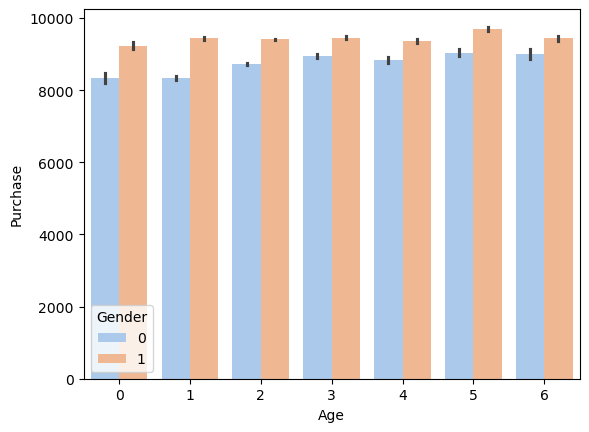

In [462]:
#Visializtion
sns.barplot(x='Age', y='Purchase', hue='Gender', data=df,palette='pastel')
plt.show()

#Purchase of menis higher then women

In [466]:
df.columns


Index(['Product_ID', 'Gender', 'Age', 'Occupation',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase', 'B', 'C'],
      dtype='object')

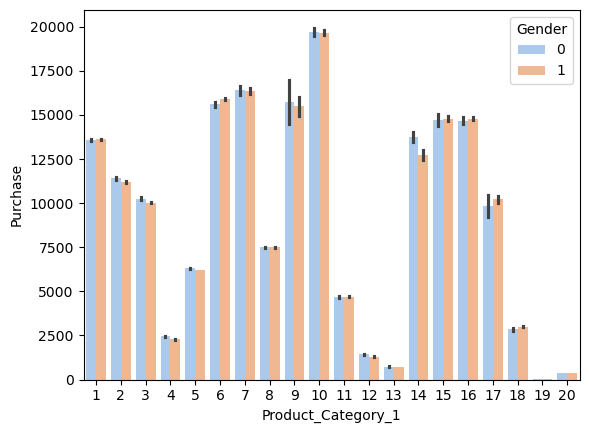

In [473]:
sns.barplot(x='Product_Category_1', y='Purchase', hue='Gender', data=df,palette='pastel')
plt.show()


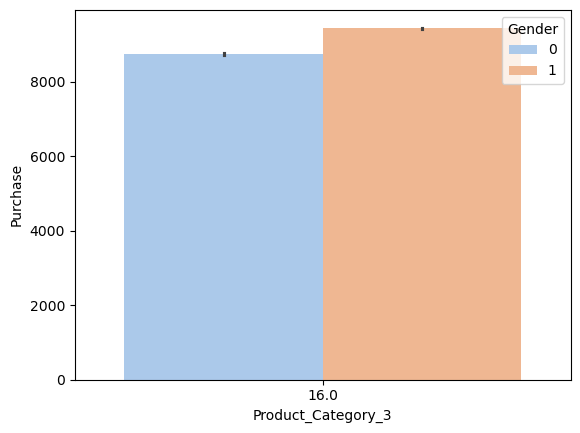

In [475]:
sns.barplot(x='Product_Category_3', y='Purchase', hue='Gender', data=df,palette='pastel')
plt.show()


In [480]:
## Feature scaling
df_test = df[df['Purchase'].isnull()] #if it is null all belong to test data

In [482]:
df_train= df[~df['Purchase'].isnull()]

In [498]:
X=df_train.drop('Purchase' , axis = 1) #there showing 1 more columns in a y so we are droping purchase

In [502]:
y=df_train['Purchase']

In [508]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [510]:
X_train.drop('Product_ID' , axis = 1 ,inplace = True)
X_test.drop('Product_ID' , axis = 1 ,inplace = True)

In [516]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test= sc.transform(X_test)

In [518]:
#train model